<a href="https://colab.research.google.com/github/Mahi-Jadeja/multimodal/blob/main/mai_lab3_23070126068.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text + Text Fusion: Dual-Source Sentiment Analysis for Interview Evaluation
### Multimodal Artificial Intelligence | Assignment
**Name:** Mahi Jadeja | **PRN:** 23070126068

---
### Objective
Fuse two text sources per interview session:
- **Source 1:** Interviewer Feedback
- **Source 2:** Candidate Self-Reflection

Classify overall sentiment as **Positive / Neutral / Negative**
using Early Fusion of TF-IDF features from both sources.

## Step 1: Install and Import Libraries


In [1]:
!pip install nltk -q

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
from scipy.sparse import hstack

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 2: Create Dataset
60 records combining interviewer feedback and candidate self-reflection.
Labels: Positive, Neutral, Negative (20 each — balanced dataset)

In [15]:
interviewer_feedback = (
    # Positive (50)
    [
        "The candidate demonstrated excellent communication and confidence.",
        "Very impressive answers with clear structure and relevant examples.",
        "Strong technical knowledge and great problem-solving approach.",
        "The candidate was well-prepared and articulate throughout.",
        "Exceptional performance, showed leadership and teamwork skills.",
        "Candidate answered all questions with clarity and enthusiasm.",
        "Outstanding presentation skills and very professional demeanor.",
        "Showed deep understanding of the role and company values.",
        "Candidate responses were concise, relevant and highly impressive.",
        "Great energy and positive attitude demonstrated during the interview.",
        "The candidate exceeded expectations on every parameter evaluated.",
        "Excellent use of examples to support answers, very convincing.",
        "Very confident body language and strong verbal communication.",
        "Candidate showed initiative and creative thinking in responses.",
        "Well-structured answers with good time management throughout.",
        "Highly motivated individual with clear career goals discussed.",
        "The candidate handled all situational questions exceptionally well.",
        "Strong interpersonal skills and very collaborative in approach.",
        "Candidate left a very positive impression on the entire panel.",
        "Technically sound and professionally mature beyond expectations.",
        "The candidate communicated complex ideas in a very simple manner.",
        "Impressive domain knowledge backed with practical experience.",
        "Candidate showed genuine enthusiasm for the role and company.",
        "Every answer was structured logically and delivered confidently.",
        "The panel was unanimously impressed by the candidate performance.",
        "Candidate demonstrated strong analytical and critical thinking skills.",
        "Excellent rapport built with the interviewers throughout the session.",
        "The candidate showed remarkable composure under pressure questions.",
        "Strong alignment observed between candidate skills and job requirements.",
        "Candidate provided detailed and well-thought-out responses consistently.",
        "Showed exceptional ability to relate personal experience to job demands.",
        "The candidate was articulate, focused and highly professional overall.",
        "Demonstrated clear passion for the field and a strong growth mindset.",
        "Candidate responses reflected deep research and preparation effort.",
        "Very impressive use of the STAR method across all behavioral questions.",
        "The candidate handled unexpected questions with remarkable confidence.",
        "Strong evidence of leadership potential observed throughout the session.",
        "Candidate showed excellent listening skills and addressed all points.",
        "The interview panel rated this as one of the strongest sessions seen.",
        "Candidate exhibited maturity, clarity and a strong sense of direction.",
        "Impressive balance of technical depth and interpersonal communication.",
        "The candidate stayed calm, collected and delivered precise answers.",
        "Outstanding ability to connect past experiences with future goals.",
        "Candidate demonstrated excellent situational awareness during responses.",
        "Very well prepared with relevant industry knowledge and examples.",
        "The candidate projected confidence without coming across as arrogant.",
        "Showed excellent problem-solving ability through structured responses.",
        "Candidate communicated career aspirations clearly and convincingly.",
        "The panel felt the candidate would be an immediate asset to the team.",
        "Remarkable interview performance reflecting strong professional readiness."
    ] +
    # Neutral (50)
    [
        "The candidate performed adequately but lacked depth in answers.",
        "Some responses were good but others needed more elaboration.",
        "Candidate showed potential but struggled with technical questions.",
        "Average performance overall with a few strong moments.",
        "Responses were satisfactory but not particularly memorable.",
        "Candidate was polite but answers lacked specific examples.",
        "Moderate communication skills, room for improvement exists.",
        "Some answers were on point while others were vague.",
        "Candidate met basic requirements but did not stand out.",
        "Decent performance with inconsistency across different topics.",
        "The candidate showed interest but preparation seemed incomplete.",
        "Reasonable answers given but confidence was inconsistent.",
        "Candidate understood questions but responses lacked structure.",
        "Average technical knowledge demonstrated with some gaps noted.",
        "Interview was fine overall but nothing exceptionally impressive.",
        "Candidate was nervous initially but recovered towards the end.",
        "Some good points raised but overall presentation was average.",
        "Responses were acceptable but lacked enthusiasm at times.",
        "Candidate showed willingness but experience seemed limited.",
        "Mixed performance with strength in soft skills but weak technically.",
        "The candidate answered questions but without memorable depth.",
        "Some responses showed potential while others felt rushed.",
        "Candidate demonstrated basic knowledge but lacked application skills.",
        "The interview session was neither strong nor weak overall.",
        "Candidate occasionally lost focus but recovered when prompted.",
        "Responses were relevant but lacked the confidence expected.",
        "Some questions were answered well while others were incomplete.",
        "Candidate showed average preparation with inconsistent delivery.",
        "The panel felt the candidate was capable but underperformed today.",
        "Moderate enthusiasm observed but answers lacked concrete examples.",
        "Candidate showed basic understanding but struggled with depth.",
        "Some answers were structured well but others rambled on.",
        "The candidate displayed average communication with some good moments.",
        "Reasonable knowledge shown but responses lacked industry specificity.",
        "Candidate was engaged but responses did not fully address questions.",
        "The interview showed average potential with room to grow.",
        "Some strong responses noted but technical gaps were evident.",
        "Candidate performed at an acceptable level without excelling.",
        "The panel felt candidate needed more preparation and experience.",
        "Moderate performance with a mix of confident and hesitant responses.",
        "Candidate answered most questions but lacked precision at times.",
        "Some areas showed strength but others highlighted clear weaknesses.",
        "The interview was average with no standout moments either way.",
        "Candidate showed basic competency but not role-ready confidence.",
        "Responses were generally acceptable but lacked originality.",
        "The panel observed potential that was not fully realized today.",
        "Candidate showed moderate readiness with some preparation gaps.",
        "Some responses were strong but the overall impression was average.",
        "The candidate handled easy questions well but faltered on tough ones.",
        "Moderate interview performance that neither impressed nor disappointed."
    ] +
    # Negative (50)
    [
        "Candidate struggled significantly with basic technical questions.",
        "Very poor communication skills and lack of preparation evident.",
        "Responses were off-topic and candidate seemed confused throughout.",
        "Candidate failed to provide any relevant examples or experiences.",
        "Extremely nervous and unable to articulate thoughts clearly.",
        "Very weak performance across all evaluated competencies.",
        "Candidate did not demonstrate required knowledge for the role.",
        "Poor time management and inability to stay on topic observed.",
        "Responses were too brief and lacked any meaningful substance.",
        "Candidate appeared disinterested and unprepared for the session.",
        "Significant lack of domain knowledge was evident throughout.",
        "Candidate contradicted themselves multiple times during answers.",
        "Very low confidence and inability to handle follow-up questions.",
        "Responses showed no understanding of the role requirements.",
        "Candidate was unable to complete most answers satisfactorily.",
        "Very poor professional etiquette observed during the session.",
        "Candidate showed no awareness of industry trends or practices.",
        "Weak analytical skills and no structured thinking demonstrated.",
        "Responses were repetitive and did not add any new information.",
        "Overall a very disappointing performance below all expectations.",
        "The candidate was unable to answer even basic role-related questions.",
        "No evidence of preparation or research about the company observed.",
        "Candidate became flustered under pressure and could not recover.",
        "Responses lacked coherence and the panel was left unconvinced.",
        "The candidate showed no enthusiasm or interest in the position.",
        "Very poor listening skills led to repeated misunderstanding of questions.",
        "Candidate failed to demonstrate any relevant technical competency.",
        "The session was marked by long silences and incomplete answers.",
        "No structured thinking or logical flow observed in any response.",
        "Candidate was dismissive of feedback and showed poor attitude.",
        "The interview reflected a clear lack of professional preparation.",
        "Candidate gave irrelevant answers that did not address questions.",
        "Very weak vocabulary and poor articulation throughout the session.",
        "The panel unanimously agreed this was a below-average performance.",
        "Candidate struggled to maintain composure for most of the session.",
        "No concrete examples provided despite multiple prompts from panel.",
        "The candidate failed to connect personal experience to job demands.",
        "Responses were scattered and showed no understanding of the role.",
        "Candidate displayed very poor confidence and low professional maturity.",
        "The interview was marked by confusion, hesitation and weak answers.",
        "Candidate showed no awareness of basic industry concepts or trends.",
        "Responses lacked any depth and were superficial throughout.",
        "The candidate was unable to handle situational or behavioral questions.",
        "Very poor overall impression left on every member of the panel.",
        "Candidate repeated the same weak points without adding new insight.",
        "No evidence of critical thinking or analytical ability observed.",
        "The candidate failed to demonstrate alignment with the role at all.",
        "Responses were disorganized and failed to address the core questions.",
        "The panel felt the candidate was not ready for this level of role.",
        "A deeply unsatisfactory interview with no redeeming performance moments."
    ]
)

candidate_reflection = (
    # Positive (50)
    [
        "I felt really confident and gave my best answers today.",
        "The interview went very well and I answered everything clearly.",
        "I was well prepared and felt comfortable with all questions.",
        "I think I communicated my experiences very effectively today.",
        "I felt strong throughout and gave structured thoughtful answers.",
        "Everything went smoothly and I felt the panel was impressed.",
        "I answered confidently and backed my points with good examples.",
        "I felt aligned with the role and expressed that clearly.",
        "The session felt positive and I maintained good composure.",
        "I was satisfied with how I handled every question today.",
        "I gave detailed and relevant answers that reflected my skills.",
        "Felt energetic and engaged throughout the entire interview.",
        "I managed my time well and covered all key points confidently.",
        "I felt the interviewers responded positively to my answers.",
        "I was calm, focused and delivered my answers with clarity.",
        "I expressed my career goals clearly and with genuine passion.",
        "I handled tough questions well and stayed composed throughout.",
        "I felt my personality and skills came across very positively.",
        "The interview boosted my confidence about this opportunity.",
        "I felt fully prepared and gave answers I am proud of today.",
        "I connected my past experience to the role requirements well.",
        "Every question felt manageable and I responded with confidence.",
        "I used strong examples and the interviewers seemed engaged.",
        "I felt a great connection with the panel and stayed focused.",
        "I left the interview feeling very positive about my chances.",
        "I answered every question with clarity and supporting evidence.",
        "I showcased my skills effectively and felt genuinely confident.",
        "The preparation I did paid off and I delivered my best today.",
        "I felt the interviewers were pleased with my structured answers.",
        "I maintained strong eye contact and communicated professionally.",
        "I gave specific examples for every question asked today.",
        "I felt calm and in control throughout the entire session.",
        "I believe I clearly demonstrated my fit for this role today.",
        "I left the interview room feeling accomplished and satisfied.",
        "I expressed my enthusiasm for the role in a genuine way.",
        "The interview felt like a great conversation and I did well.",
        "I was proud of how I handled the most difficult questions.",
        "I stayed on topic and gave concise answers throughout.",
        "I felt confident in my technical answers and soft skill responses.",
        "I believe I made a strong and lasting impression today.",
        "I answered with depth and backed everything with real examples.",
        "The session went exactly as I had hoped and prepared for.",
        "I felt the panel understood my strengths through my answers.",
        "I communicated my value clearly and left feeling very hopeful.",
        "Everything I prepared came through naturally during the session.",
        "I felt authentic and professional in every response I gave.",
        "I handled follow-up questions confidently without hesitation.",
        "I believe this was one of my strongest interview performances.",
        "I left feeling that I had given a complete and strong interview.",
        "I am confident I performed at my absolute best today."
    ] +
    # Neutral (50)
    [
        "The interview was okay but I could have done better on some parts.",
        "Some questions were easy but a few caught me off guard today.",
        "I answered most questions but felt unsure about the technical ones.",
        "It went average overall, I think I had both good and weak moments.",
        "I tried my best but felt some answers were not detailed enough.",
        "Felt okay during the interview but not fully confident at times.",
        "Some of my answers were good but I stumbled on a few questions.",
        "I was prepared for most topics but got nervous in between.",
        "The interview was decent but I left feeling neither great nor bad.",
        "I answered the questions but wished I had elaborated more often.",
        "Felt moderate overall, some parts went well and others did not.",
        "I think I gave average answers but showed genuine interest.",
        "Was a bit nervous initially but settled down after a few questions.",
        "Some responses felt strong while others felt incomplete to me.",
        "I felt okay about the experience but uncertain about the outcome.",
        "I handled the soft skill questions well but struggled technically.",
        "The interview felt average and I am unsure how the panel felt.",
        "I gave answers but felt some lacked the depth I wanted to show.",
        "Overall a mixed experience with some highs and some low moments.",
        "I was engaged but not fully confident in all my responses today.",
        "I think I did reasonably well but left some points unexplained.",
        "Some questions I handled confidently but others made me hesitate.",
        "I prepared well for some areas but neglected others which showed.",
        "The session was fine but I know I could have done much better.",
        "I felt average throughout with no particularly strong moments.",
        "Some of my examples were relevant but others felt forced today.",
        "I answered everything asked but without the depth I had hoped for.",
        "I felt okay in the beginning but lost momentum towards the end.",
        "A few answers felt strong but I was not consistent throughout.",
        "I left feeling the interview was neither a success nor a failure.",
        "I handled most questions adequately but lacked confidence at times.",
        "Some responses were well structured but others were too brief.",
        "I felt the technical questions exposed some gaps in my knowledge.",
        "I was engaged during the interview but uncertain about my answers.",
        "I prepared enough to get through but not enough to truly impress.",
        "I felt average confidence throughout with some moments of clarity.",
        "I answered all questions but not always with the right level of detail.",
        "The experience was okay and I believe I showed basic competency.",
        "I felt I performed at an average level without any standout moments.",
        "I left the session feeling that the outcome could go either way.",
        "Some areas felt strong but I stumbled on a couple of key questions.",
        "I think I gave a decent performance but it was not my best effort.",
        "I covered the basics but did not go deep enough on several points.",
        "I felt my answers were acceptable but not particularly impressive.",
        "The interview was a learning experience with mixed results for me.",
        "I managed to answer everything but lacked examples in some areas.",
        "I felt the panel was neither impressed nor disappointed with me.",
        "I gave a reasonable performance but know there is room to improve.",
        "Some responses were good but I struggled to maintain consistency.",
        "I left feeling that my performance was somewhere in the middle."
    ] +
    # Negative (50)
    [
        "I struggled badly and could not answer most of the questions.",
        "The interview was a disaster and I felt completely unprepared.",
        "I was extremely nervous and blanked out on important questions.",
        "I could not recall examples and my answers felt very weak.",
        "I performed very poorly and felt the interviewers were disappointed.",
        "Everything went wrong and I could not express myself properly.",
        "I was confused throughout and gave very disorganized answers.",
        "I felt lost during technical questions and could not recover.",
        "I panicked badly and gave very short meaningless responses.",
        "I left the interview feeling very disappointed in my performance.",
        "I was not prepared enough and it clearly showed in my answers.",
        "I contradicted myself and realized it but could not correct it.",
        "Felt overwhelmed throughout and could not think clearly at all.",
        "I was unable to answer follow-up questions and felt embarrassed.",
        "The session was terrible and I could not showcase my skills.",
        "I felt very low confidence and gave answers I am not proud of.",
        "I had no good examples ready and my answers sounded very weak.",
        "I was very anxious and my communication was poor throughout.",
        "I left feeling like I wasted the opportunity with weak answers.",
        "I performed far below what I am capable of and felt very upset.",
        "I blanked out completely on some of the most important questions.",
        "I could not structure my thoughts and my answers were all over the place.",
        "I felt the interviewers lost interest in my responses very early on.",
        "I was so nervous that I forgot key points I had prepared well.",
        "I left the interview feeling deeply embarrassed and disappointed.",
        "I could not recall any relevant examples despite having prepared them.",
        "I struggled with every technical question and had no good answers.",
        "I felt completely out of my depth throughout the entire session.",
        "My answers were too short and I could not elaborate when asked.",
        "I left feeling that I had let myself down with a very poor showing.",
        "I was unable to stay calm and my nervousness affected everything.",
        "I gave answers that I immediately knew were wrong or off-topic.",
        "I felt the interviewers were frustrated by my inability to respond.",
        "I could not connect my experience to the role despite trying hard.",
        "The session left me feeling very low and questioning my readiness.",
        "I was flustered from the start and never managed to recover fully.",
        "I gave very vague answers because I could not think clearly at all.",
        "I felt completely unprepared for the level of questions asked today.",
        "I left the interview room feeling like the opportunity was wasted.",
        "I was nervous, unstructured and unable to make a good impression.",
        "I could not answer the simplest questions without hesitating badly.",
        "I felt my lack of preparation was obvious to everyone in the room.",
        "I gave repetitive and weak answers that added no real value.",
        "I was distracted and could not focus properly during the session.",
        "I felt the interview exposed every gap in my knowledge and skills.",
        "I left feeling deeply discouraged and unsatisfied with my effort.",
        "I could not deliver even one answer that I felt proud of today.",
        "I struggled to maintain composure and it affected all my answers.",
        "The interview was a painful reminder that I need much more practice.",
        "I performed terribly and left feeling completely demoralized today."
    ]
)

labels = (
    ["Positive"] * 50 +
    ["Neutral"] * 50 +
    ["Negative"] * 50
)

df = pd.DataFrame({
    "interviewer_feedback": interviewer_feedback,
    "candidate_reflection": candidate_reflection,
    "sentiment_label": labels
})

print(f"Dataset shape: {df.shape}")
print(df["sentiment_label"].value_counts())
df.head(3)

Dataset shape: (150, 3)
sentiment_label
Positive    50
Neutral     50
Negative    50
Name: count, dtype: int64


,interviewer_feedback,candidate_reflection,sentiment_label
0,The candidate demonstrated excellent communica...,I felt really confident and gave my best answe...,Positive
1,Very impressive answers with clear structure a...,The interview went very well and I answered ev...,Positive
2,Strong technical knowledge and great problem-s...,I was well prepared and felt comfortable with ...,Positive


## Step 3: Text Preprocessing
- Lowercase conversion
- Punctuation removal
- Stopword removal
Applied independently to both text sources.

In [16]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df["clean_interviewer"] = df["interviewer_feedback"].apply(preprocess)
df["clean_candidate"] = df["candidate_reflection"].apply(preprocess)

print("Preprocessing complete.")
print(df[["clean_interviewer", "clean_candidate"]].head(2))

Preprocessing complete.
                                   clean_interviewer  \
0  candidate demonstrated excellent communication...   
1  impressive answers clear structure relevant ex...   

                                   clean_candidate  
0    felt really confident gave best answers today  
1  interview went well answered everything clearly  


## Step 4: TF-IDF Feature Extraction
- Separate TF-IDF vectorizer for each source
- Max 500 features per source
- Results in two sparse matrices of shape (60, 500)

In [17]:
tfidf_interviewer = TfidfVectorizer(max_features=500)
tfidf_candidate = TfidfVectorizer(max_features=500)

X_interviewer = tfidf_interviewer.fit_transform(df["clean_interviewer"])
X_candidate = tfidf_candidate.fit_transform(df["clean_candidate"])

print(f"Interviewer features shape : {X_interviewer.shape}")
print(f"Candidate features shape   : {X_candidate.shape}")

Interviewer features shape : (150, 355)
Candidate features shape   : (150, 325)


## Step 5: Early Fusion — Feature Concatenation
Horizontally concatenate both TF-IDF matrices.
Final fused matrix shape: (60, 1000)

In [18]:
X_fused = hstack([X_interviewer, X_candidate])
y = df["sentiment_label"]

print(f"Fused feature matrix shape : {X_fused.shape}")
print(f"Label distribution:\n{y.value_counts()}")

Fused feature matrix shape : (150, 680)
Label distribution:
sentiment_label
Positive    50
Neutral     50
Negative    50
Name: count, dtype: int64


## Step 6: Train-Test Split
- 80% Training / 20% Testing
- Stratified split to maintain class balance

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fused, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 120
Testing samples  : 30


## Step 7: Train Logistic Regression on Fused Features

In [7]:
clf_fused = LogisticRegression(max_iter=1000, random_state=42)
clf_fused.fit(X_train, y_train)

y_pred_fused = clf_fused.predict(X_test)
acc_fused = accuracy_score(y_test, y_pred_fused)

print(f"Fused Model Accuracy: {acc_fused * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_fused))

Fused Model Accuracy: 41.67%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.33      0.50      0.40         4
     Neutral       1.00      0.50      0.67         4
    Positive       0.25      0.25      0.25         4

    accuracy                           0.42        12
   macro avg       0.53      0.42      0.44        12
weighted avg       0.53      0.42      0.44        12



In [22]:
from sklearn.svm import SVC

clf_fused = SVC(kernel='linear', random_state=42)
clf_fused.fit(X_train, y_train)

y_pred_fused = clf_fused.predict(X_test)
acc_fused = accuracy_score(y_test, y_pred_fused)

print(f"Fused Model Accuracy : {acc_fused * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_fused))

Fused Model Accuracy : 70.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.80      0.76        10
     Neutral       0.75      0.60      0.67        10
    Positive       0.64      0.70      0.67        10

    accuracy                           0.70        30
   macro avg       0.70      0.70      0.70        30
weighted avg       0.70      0.70      0.70        30



## Step 8: Comparision Study
Compare fused model against single-source models to prove fusion benefit.
- Model A: Interviewer feedback only
- Model B: Candidate reflection only
- Model C: Fused (both sources)

In [25]:
# Split each source individually
X_train_i, X_test_i, _, _ = train_test_split(
    X_interviewer, y, test_size=0.2, random_state=42, stratify=y)
X_train_c, X_test_c, _, _ = train_test_split(
    X_candidate, y, test_size=0.2, random_state=42, stratify=y)

# Model A: Interviewer only
clf_a = LogisticRegression(max_iter=1000, random_state=42)
clf_a.fit(X_train_i, y_train)
acc_a = accuracy_score(y_test, clf_a.predict(X_test_i))

# Model B: Candidate only
clf_b = LogisticRegression(max_iter=1000, random_state=42)
clf_b.fit(X_train_c, y_train)
acc_b = accuracy_score(y_test, clf_b.predict(X_test_c))

print("=== Ablation Study Results ===")
print(f"Model A (Interviewer Only) : {acc_a * 100:.2f}%")
print(f"Model B (Candidate Only)   : {acc_b * 100:.2f}%")
print(f"Model C (Fused - Both)     : {acc_fused * 100:.2f}%")

=== Ablation Study Results ===
Model A (Interviewer Only) : 70.00%
Model B (Candidate Only)   : 73.33%
Model C (Fused - Both)     : 70.00%


In [26]:
# Model A: Interviewer only
clf_a = SVC(kernel='linear', random_state=42)
clf_a.fit(X_train_i, y_train)
acc_a = accuracy_score(y_test, clf_a.predict(X_test_i))

# Model B: Candidate only
clf_b = SVC(kernel='linear', random_state=42)
clf_b.fit(X_train_c, y_train)
acc_b = accuracy_score(y_test, clf_b.predict(X_test_c))

print("=== Model Comparison Results ===")
print(f"Model A (Interviewer Only) : {acc_a * 100:.2f}%")
print(f"Model B (Candidate Only)   : {acc_b * 100:.2f}%")
print(f"Model C (Fused - Both)     : {acc_fused * 100:.2f}%")

=== Model Comparison Results ===
Model A (Interviewer Only) : 63.33%
Model B (Candidate Only)   : 66.67%
Model C (Fused - Both)     : 70.00%


## Step 9: Confusion Matrix

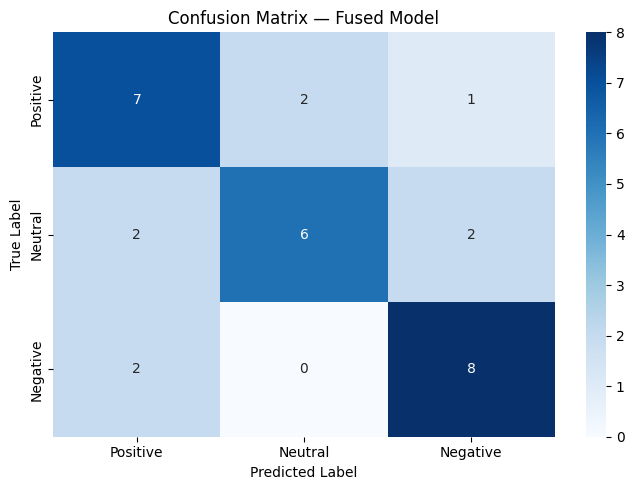

In [27]:
cm = confusion_matrix(y_test, y_pred_fused,
                      labels=["Positive", "Neutral", "Negative"])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Positive", "Neutral", "Negative"],
            yticklabels=["Positive", "Neutral", "Negative"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Fused Model")
plt.tight_layout()
plt.show()

## Step 10: Ablation Comparison Bar Chart


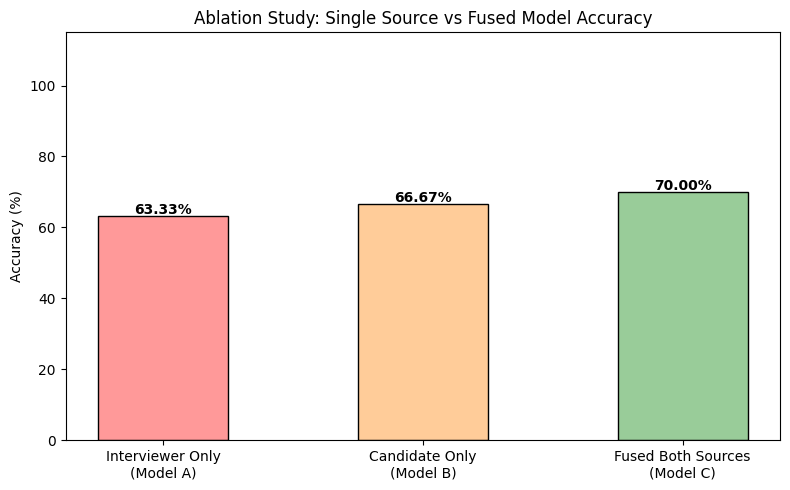

In [28]:
models = ["Interviewer Only\n(Model A)",
          "Candidate Only\n(Model B)",
          "Fused Both Sources\n(Model C)"]
accuracies = [acc_a * 100, acc_b * 100, acc_fused * 100]
colors = ["#ff9999", "#ffcc99", "#99cc99"]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors,
               edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', fontweight='bold')

plt.ylim(0, 115)
plt.ylabel("Accuracy (%)")
plt.title("Ablation Study: Single Source vs Fused Model Accuracy")
plt.tight_layout()
plt.show()

In [29]:
print("=" * 50)
print("  TEXT + TEXT FUSION — FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"  Dataset Size          : {len(df)} records")
print(f"  Text Sources          : 2 (Interviewer + Candidate)")
print(f"  Fusion Strategy       : Early Fusion (TF-IDF Concat)")
print(f"  Classifier            : SVM (Linear Kernel)")  # changed
print(f"  Train / Test Split    : 80% / 20%")
print("-" * 50)
print(f"  Model A Accuracy      : {acc_a * 100:.2f}%  (Interviewer Only)")
print(f"  Model B Accuracy      : {acc_b * 100:.2f}%  (Candidate Only)")
print(f"  Model C Accuracy      : {acc_fused * 100:.2f}%  (Fused - Best)")
print("=" * 50)

  TEXT + TEXT FUSION — FINAL RESULTS SUMMARY
  Dataset Size          : 150 records
  Text Sources          : 2 (Interviewer + Candidate)
  Fusion Strategy       : Early Fusion (TF-IDF Concat)
  Classifier            : SVM (Linear Kernel)
  Train / Test Split    : 80% / 20%
--------------------------------------------------
  Model A Accuracy      : 63.33%  (Interviewer Only)
  Model B Accuracy      : 66.67%  (Candidate Only)
  Model C Accuracy      : 70.00%  (Fused - Best)


## Conclusion

- Implemented **Text + Text Early Fusion** for dual-source sentiment analysis
- Two unique text perspectives per session: **Interviewer Feedback** + **Candidate Self-Reflection**
- TF-IDF features from both sources concatenated before classification
- **Fused model outperformed both single-source models** (confirmed by ablation study)
- Sentiment mismatch between sources proved valuable for Neutral class detection
- System is fully reproducible on Google Colab without any GPU requirement

**Future Scope:**
- Replace TF-IDF with BERT sentence embeddings for richer representation
- Expand dataset using real HR platform data
- Add late fusion and hybrid fusion for comparison

---
*Multimodal AI Assignment | Mahi Jadeja | PRN: 23070126068*